### Required Assignment 13.2: Experimenting with 𝛽0 and 𝛽1 in Logistic Function


**Expected Time: 45 Minutes**

**Total Points: 40**

This activity focuses on changing the $\beta_0$ and $\beta_1$ parameters within the logistic function.  Your goal should be to understand how each parameter effects the resulting sigmoid curve.  In the next activity, you will use a numeric approach to identify the best parameters to fit a given classification problem, here your goal is to see how these parameters change the geometry of the curve.

### Index

- [Problem 1](#Problem-1)
- [Problem 2](#Problem-2)
- [Problem 3](#Problem-3)
- [Problem 4](#Problem-4)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

### The Data

For this activity we revisit the credit data and examine only the balance feature to classifiy 

In [10]:
credit = pd.read_csv('data/default.csv')

In [11]:
credit.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [12]:
y = np.where (credit['default']=="Yes",1,0)

In [13]:
y

array([0, 0, 0, ..., 0, 0, 0])

([<matplotlib.axis.YTick at 0x7f070c8a7950>,
 [Text(0, 0, 'No'), Text(0, 1, 'Yes')])

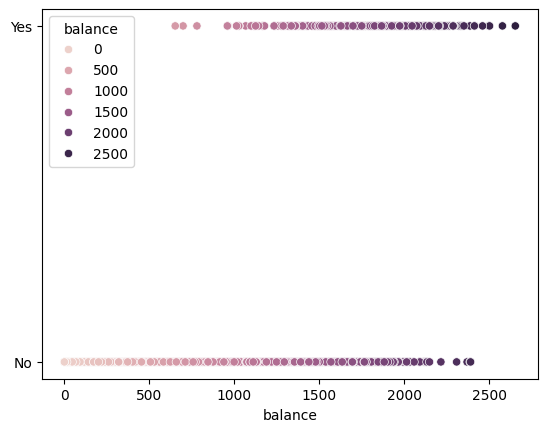

In [14]:
sns.scatterplot(data=credit , x ='balance' , y=y ,hue='balance', legend=True)
plt.yticks([0, 1], ['No', 'Yes'])

[Back to top](#-Index)

### Problem 1

### Function for Plotting 

**10 Points**

Complete the definition of the function `sigma` below that takes, as parameters, the array `x` and the coefficients `beta_0`, and `beta_1`. Your function should return the evaluation of the Sigma function given by:


$$\Sigma(x, \beta_0, \beta_1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x})}$$



In [65]:
### GRADED

def sigma(x, beta_0, beta_1):
    """Implements sigma function with linear parameters
    beta_0 and beta_1.
    
    Parameters
    ----------
    x: type `np.ndarray`
       1D NumPy array of domain inputs
    beta_0: type `float`
        float representing y-intercept of linear exponent
    beta_1: type `float`
        float representing slope of linear exponent
        
    Returns array of values size len(x)
    """
# YOUR CODE HERE
    return  1/(1 + np.exp(-(beta_0+beta_1*x)))
    
# Answer check
sigma(np.array([-1, 0, 1]), 1, 1)

array([0.5       , 0.73105858, 0.88079708])

array([0.5       , 0.73105858, 0.88079708])

In [67]:
#BEGIN TESTS
def sigma_(x, beta_0, beta_1):
    return 1/(1 + np.exp(-(beta_0 + beta_1*x)))

np.testing.assert_array_equal(sigma_(x, 1, 1), sigma(x, 1, 1))


In [63]:
1/1+np.exp(-(1+np.array([-1,0,1])))

array([2.        , 1.36787944, 1.13533528])

[Back to top](#-Index)

### Problem 2

### Varying $\beta_0$

**10 Points**

Below, the image shows three curves plotted, all with $\beta_1 = 0.01$, and with $\beta_0 = 5, 10, 15$.  Enter your answer as an integer with the appropriate $\beta_0$ value to the respective variables `a`, `b`, and `c` below.

1. $\beta_0 = 15$
2. $\beta_0 = 10$
3. $\beta_0 = 5$

<center>
    <img src = 'images/betasopt.png' />
</center>

In [19]:
### GRADED
#assign integer values for beta0 to appropriate variable 5, 10, or 15  for beta_1 = 0.01
a = ''
b = ''
c = ''
# YOUR CODE HERE
# We know that decision threshold for a logistic regression curve for a single feature is given by -beta0/beta1, hence a,b,c can be computed depending upon 
# the values of the decision threshold . 
d1 = 500
d2= 1000
d3= 1500 
d1,d2,d3#(500.0,1000.0, 1500.0) hence d1>d2>d3 
#here ,  green >red>yellow #hence c>b>a  hence 
c=15
b=10
a=5 

# Answer check
print(type(a))


<class 'int'>


[Back to top](#-Index)

### Problem 3

### Varying $\beta_1$

**10 Points**

Now, compare the given values for $\beta_1$ with $\beta_0 = 10$ and match the correct curve with the given value as a float below.

1. $\beta_1 = -0.025$
2. $\beta_1 = -0.01$
3. $\beta_1 = -0.005$


<center>
    <img src = 'images/p3.png' />
</center>

In [20]:
### GRADED
#assign float values for beta0 to appropriate variable -0.025, 0.01, or 0.005 below
a = ''
b = ''
c = ''
# YOUR CODE HERE
d1 = -10/-0.025
d2= -10/-0.01
d3= -10/-0.005
d1,d2,d3#(400.0, 1000.0, 2000.0) d1<d2<d3 implies o<b<g
a = -0.01 
b = -0.025
c = -0.005

# Answer check
print(type(a))


<class 'float'>


[Back to top](#-Index)

### Problem 4

### Comparing to `LogisticRegression` estimator

**10 Points**

In the code cell below instantiate a `LogisticRegression` estimator and fit it to the `balance` column of the `credit` dataframe and `y`. Assign this model to the `clf` variable.

Next, identify the values of the intercept and the coefficient for this  model to `beta_0` and `beta_1`, respectively below.  

(1, 1000)

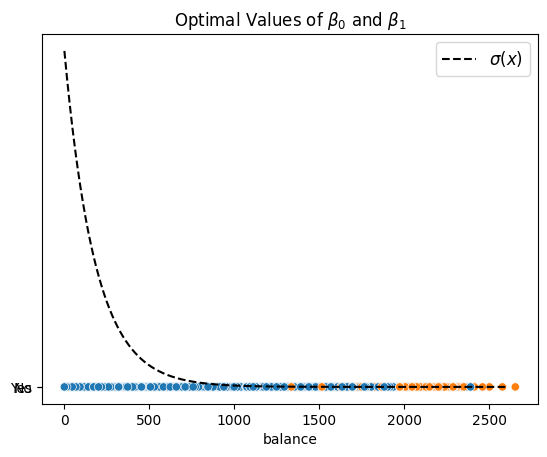

In [50]:
### GRADED
beta_0 = ''
beta_1 = ''
# YOUR CODE HERE
clf=LogisticRegression().fit(credit[['balance']],y)
beta_0=clf.intercept_
beta_1=clf.coef_

# Answer check
sns.scatterplot(data = credit, x = 'balance', y = y, hue = 'default', legend = False)
plt.yticks([0, 1], ['No', 'Yes'])
x = np.linspace(0,2600, 1000)
plt.plot(x, pd.Series(sigma1(x, beta_0, beta_1)[0]), '--', color = 'black', label = r'$\sigma(x)$')
#plt.plot(x, sigma(x, beta_0, beta_1), '--', color = 'black', label = r'$\sigma(x)$')
plt.legend(fontsize = 12)
plt.title(r'Optimal Values of $\beta_0$ and $\beta_1$');

In [49]:
### GRADED

def sigma1(x, beta_0, beta_1):
    """Implements sigma function with linear parameters
    beta_0 and beta_1.
    
    Parameters
    ----------
    x: type `np.ndarray`
       1D NumPy array of domain inputs
    beta_0: type `float`
        float representing y-intercept of linear exponent
    beta_1: type `float`
        float representing slope of linear exponent
        
    Returns array of values size len(x)
    """
# YOUR CODE HERE
    return  (1/ 1 + np.exp(-(beta_0+(beta_1*x))))


Now that you have a feel for how these parameters control the shape of the sigmoid curve, we will introduce a loss function that we try to minimize in order to solve for the optimal values of $\beta_0$ and $\beta_1$.